In [2]:
!pip install -q scikit-learn numpy tqdm matplotlib
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import librosa
import numpy as np
import os
from tqdm import tqdm

DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/datasets"

def extract_features(file_path, sr=22050, duration=10, n_mfcc=20):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        # Mean over time
        mfcc_mean = np.mean(mfcc.T, axis=0)
        return mfcc_mean
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [6]:
features, labels, groups, filenames = [], [], [], []
label_map = {}
genre_id = 0

for genre in os.listdir(DATASET_PATH):
    genre_path = os.path.join(DATASET_PATH, genre)
    if not os.path.isdir(genre_path):
        continue
    label_map[genre] = genre_id
    print(f"Processing Genre: {genre}")

    for lang_folder in os.listdir(genre_path):
        lang_path = os.path.join(genre_path, lang_folder)
        if not os.path.isdir(lang_path):
            continue

        for file in tqdm(os.listdir(lang_path)):
            if file.endswith(".mp3"):
                file_path = os.path.join(lang_path, file)
                feat = extract_features(file_path)
                if feat is not None:
                    features.append(feat)
                    labels.append(genre_id)
                    groups.append(file)
                    filenames.append(file_path)

    genre_id += 1

X = np.array(features)
y = np.array(labels)

print("Feature Matrix:", X.shape)
print("Label Count:", len(np.unique(y)))
print("Genres:", label_map)


Processing Genre: Hip-Hop


100%|██████████| 25/25 [00:01<00:00, 13.63it/s]


Processing Genre: film


100%|██████████| 48/48 [00:04<00:00, 11.19it/s]


Processing Genre: Pop


...

Processing Genre: Rock


100%|██████████| 27/27 [00:01<00:00, 14.26it/s]


Processing Genre: Classical


100%|██████████| 22/22 [00:01<00:00, 14.61it/s]

Feature Matrix: (1211, 20)
Label Count: 8
Genres: {'Hip-Hop': 0, 'film': 1, 'Pop': 2, 'metal': 3, 'Folk': 4, 'Devotional': 5, 'EDM': 6, 'Rock': 7, 'Classical': 8}


In [7]:
np.savez("/content/drive/MyDrive/ISBInternshipAIML/features_mfcc_10s.npz",
         X=X, y=y, groups=np.array(groups), label_map=label_map, filenames=filenames)
print("Saved extracted features.")

Saved extracted features.


In [8]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load saved data
data = np.load("/content/drive/MyDrive/ISBInternshipAIML/features_mfcc_10s.npz", allow_pickle=True)
X = data["X"]
y = data["y"]
groups = data["groups"]
label_map = data["label_map"].item()
inv_label_map = {v: k for k, v in label_map.items()}

# Group split: ensures same song not in both train & test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(X, y, groups):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train genres:", np.unique(y_train))
print("Test genres:", np.unique(y_test))


Train size: 969 Test size: 242
Train genres: [0 1 2 4 5 6 7 8]
Test genres: [0 1 2 4 5 6 7 8]


In [9]:
rf = RandomForestClassifier(
    n_estimators=300,      # number of trees
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc*100:.2f}%")

unique_labels = np.unique(y_test)
present_names = [inv_label_map[i] for i in unique_labels]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, labels=unique_labels, target_names=present_names, zero_division=0))


Random Forest Accuracy: 38.43%

Classification Report:
              precision    recall  f1-score   support

     Hip-Hop       0.40      0.46      0.42        46
        film       0.26      0.26      0.26        34
         Pop       0.31      0.21      0.25        39
        Folk       0.30      0.48      0.37        44
  Devotional       0.20      0.05      0.08        20
         EDM       0.60      0.67      0.63        46
        Rock       0.50      0.20      0.29         5
   Classical       1.00      0.12      0.22         8

    accuracy                           0.38       242
   macro avg       0.45      0.31      0.32       242
weighted avg       0.39      0.38      0.37       242



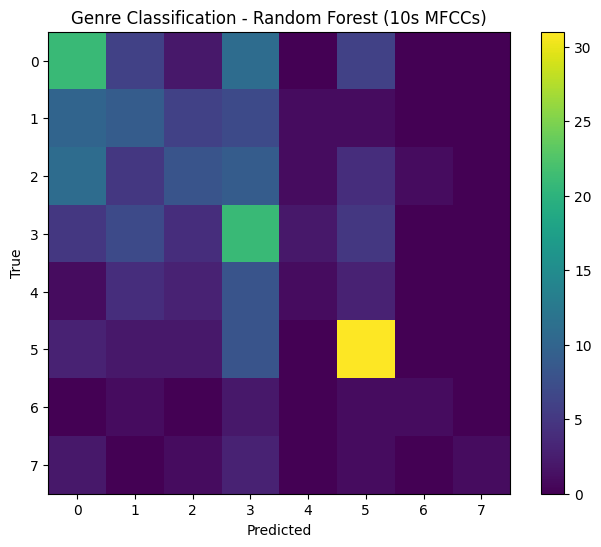

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="viridis")
plt.title("Genre Classification - Random Forest (10s MFCCs)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.colorbar()
plt.show()


Did not work

In [ ]:
from google.colab import drive
import os
import pandas as pd

try:
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except Exception as e:
    print(f"❌ Error mounting Google Drive: {e}")



root_folder_path = '/content/drive/MyDrive/ISBInternshipAIML/datasets'

# -----------------
# STEP 3: Walk through folders and count files
# -----------------
folder_data = []

# Check if the path exists to avoid errors
if os.path.exists(root_folder_path):
    print(f"\nScanning folder: {root_folder_path}...")
    # os.walk() goes through each directory, one by one
    for dirpath, dirnames, filenames in os.walk(root_folder_path):
        # The number of files is the length of the 'filenames' list
        file_count = len(filenames)
        folder_data.append({'Folder Path': dirpath, 'Number of Files': file_count})
    print("✅ Scan complete!")
else:
    print(f"❌ ERROR: The path '{root_folder_path}' does not exist.")
    print("Please check the folder path in Step 2 and try again.")


# -----------------
# STEP 4: Display the results in a clean table
# -----------------
if folder_data:
    # Create a pandas DataFrame for nice formatting
    df = pd.DataFrame(folder_data)

    # Set display options to show the full folder path without truncation
    pd.set_option('display.max_colwidth', None)

    print("\n--- File Count Results ---")
    display(df)

Mounted at /content/drive
✅ Google Drive mounted successfully!

Scanning folder: /content/drive/MyDrive/ISBInternshipAIML/datasets...
✅ Scan complete!

--- File Count Results ---


,Folder Path,Number of Files
0,/content/drive/MyDrive/ISBInternshipAIML/datasets,0
1,/content/drive/MyDrive/ISBInternshipAIML/datasets/Hip-Hop,0
2,/content/drive/MyDrive/ISBInternshipAIML/datasets/Hip-Hop/Tamil,54
3,/content/drive/MyDrive/ISBInternshipAIML/datasets/Hip-Hop/Hindi,53
4,/content/drive/MyDrive/ISBInternshipAIML/datasets/Hip-Hop/Malayalam,48
5,/content/drive/MyDrive/ISBInternshipAIML/datasets/Hip-Hop/English,25
6,/content/drive/MyDrive/ISBInternshipAIML/datasets/Hip-Hop/Spanish,25
7,/content/drive/MyDrive/ISBInternshipAIML/datasets/film,0
8,/content/drive/MyDrive/ISBInternshipAIML/datasets/film/Hindi,44
9,/content/drive/MyDrive/ISBInternshipAIML/datasets/film/Tamil,44
